<a href="https://colab.research.google.com/github/PedroHNeves1505/CP2_SERS_Semestre_2/blob/main/CP2_SERS_Semestre_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CP2 | SERS | 2° Semestre**

*INTEGRANTE*

Nome: Pedro Henrique Neves<br>
RM:   571382

*BIBILIOTECAS*

In [28]:
import pandas as pd
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

*PROJETO*

In [ ]:
# 1. Fonte de Dados

# Informações do projeto
cidade = "São Paulo (SP)"
lat = -23.55
lon = -46.63
start_year = 2020
end_year = 2020

# Parâmetros para API
peakpower = 1.0
loss = 14.0

# URL do PVGIS
url = f"https://re.jrc.ec.europa.eu/api/v5_3/seriescalc?lat={lat}&lon={lon}&peakpower={peakpower}&loss={loss}&outputformat=csv&startyear={start_year}&endyear={end_year}&pvcalculation=1"

print("=== REGISTRO DA ATIVIDADE ===")
print(f"Cidade: {cidade}")
print(f"Latitude: {lat}")
print(f"Longitude: {lon}")
print(f"Período consultado: De {start_year} até {end_year}")
print(f"Endereço (URL) utilizado:\n{url}\n")

=== REGISTRO DA ATIVIDADE ===
Cidade: São Paulo (SP)
Latitude: -23.55
Longitude: -46.63
Período consultado: De 2020 até 2020
Endereço (URL) utilizado:
https://re.jrc.ec.europa.eu/api/v5_3/seriescalc?lat=-23.55&lon=-46.63&peakpower=1.0&loss=14.0&outputformat=csv&startyear=2020&endyear=2020&pvcalculation=1



In [ ]:
# 2. Obtenção e Organização dos Dados

print("=== BAIXANDO E LENDO OS DADOS DA API ===")

# 3. Obtendo .csv do PVGIS
response = requests.get(url)
response.raise_for_status()

# Organizando o .csv com os metadados
linhas = response.text.splitlines()
linha_inicio = 0

for i, linha in enumerate(linhas):
    if 'time' in linha.lower() or 'date' in linha.lower():
        linha_inicio = i
        break

# Trazendo o database como variável python
csv_data = "\n".join(linhas[linha_inicio:])
df = pd.read_csv(io.StringIO(csv_data), on_bad_lines='skip')

# Exibindo as primeiras 5 linhas do db
display(df.head())

=== BAIXANDO E LENDO OS DADOS DA API ===


,time,P,G(i),H_sun,T2m,WS10m,Int
0,20200101:0003,0.0,0.0,0.0,22.79,1.72,0.0
1,20200101:0103,0.0,0.0,0.0,22.32,1.72,0.0
2,20200101:0203,0.0,0.0,0.0,21.90,1.59,0.0
3,20200101:0303,0.0,0.0,0.0,21.47,1.52,0.0
4,20200101:0403,0.0,0.0,0.0,21.18,1.52,0.0


In [ ]:
# 3. Inspeção Inicial do DataFrame
print('INSPEÇÂO INICIAL DO DATAFRAME')
print(f'\n{'=~' * 30}\n')

# Exibindo quantidade de linhas e colunas da tabela
linhas, colunas = df.shape

print(f'Quantidade de linhas: {linhas}')
print(f'Quantidade de colunas: {colunas}')

print(f'\n{'=~' * 30}\n')

# Identificando e mudando os nomes dos tópicos
print("Nomes exatos das colunas no CSV:", list(df.columns))

# Renoameando nomes das colunas
df = df.rename(columns={
    'time': 'Data_Hora',
    'P': 'Potencia_Fotovoltaica',
    'G(i)': 'Irradiancia_Solar',
    'T2m': 'Temperatura',
    'WS10m': 'Velocidade_Vento',
    'H_sun': 'Altura_Solar'
})

# Exibindo nomes renomeados das colunas
print(f'\n{'=~' * 30}\n')
print("Nomes renomeados das colunas no CSV:", list(df.columns))

# Exibindo tipos de dados das colunas
print(f'\n{'=~' * 30}\n')
print('Tipos de dados das colunas do DataFrame:')
print(df.dtypes)

# Exibindo quantidade de valores ausentes
print(f'\n{'=~' * 30}\n')
print('Valores Ausentes?:')
print(df.isnull().sum())

# Apagando linhas com valores ausentes
df = df.dropna(subset=['Potencia_Fotovoltaica', 'Irradiancia_Solar'])

# Conferindo se apagaou linhas com valores ausentes
print(f'\n{'=~' * 30}\n')
print('Valores Ausentes?:')
print(df.isnull().sum())

# Exibindo estatísticas principais de variáveis num
print(f'\n{'=~' * 30}\n')
print('Estatísticas Principais das Variáveis Numéricas:')
print(df.describe())

# Exibindo registros em geração ou irradiança
print(f'\n{'=~' * 30}\n')
print('Registros que apresentam periódos sem geração ou sem irradiança?:')

sem_geracao = (df['Potencia_Fotovoltaica'] == 0).sum()
sem_irradiancia = (df['Irradiancia_Solar'] == 0).sum()
ambos_zero = ((df['Potencia_Fotovoltaica'] == 0) & (df['Irradiancia_Solar'] == 0)).sum()

print(f'- Registros sem geração (Potencia_Fotovoltaica = 0): {sem_geracao}')
print(f'- Registros sem irradiança (Irradiancia_Solar = 0): {sem_irradiancia}')
print(f'- Registros com ambos zero (geralmente período noturno): {ambos_zero}')
print(f'\n{'=~' * 30}')

INSPEÇÂO INICIAL DO DATAFRAME

=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~

Quantidade de linhas: 8791
Quantidade de colunas: 7

=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~

Nomes exatos das colunas no CSV: ['time', 'P', 'G(i)', 'H_sun', 'T2m', 'WS10m', 'Int']

=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~

Nomes renomeados das colunas no CSV: ['Data_Hora', 'Potencia_Fotovoltaica', 'Irradiancia_Solar', 'Altura_Solar', 'Temperatura', 'Velocidade_Vento', 'Int']

=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~

Tipos de dados das colunas do DataFrame:
Data_Hora                 object
Potencia_Fotovoltaica     object
Irradiancia_Solar        float64
Altura_Solar             float64
Temperatura              float64
Velocidade_Vento         float64
Int                      float64
dtype: object

=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~

Valores Ausentes?:
Data_Hora                0
Potencia_Fotovoltaica    6
Ir

Optou-se por manter os registros noturnos (períodos em que a irradiação $Irradiancia Solar = 0$ e a potência $PotenciaFotovoltaica = 0$) no conjunto de dados.<br>Justificativa: Os dados noturnos representam o comportamento físico real de uma usina fotovoltaica ao longo do ciclo diário de 24 horas. Excluir esses dados poderia introduzir um viés no modelo, fazendo com que ele ignore os momentos de inatividade e prejudique previsões contínuas de longo prazo. Além disso, a manutenção preserva a integridade cronológica da série temporal horária.

In [ ]:
# 4. Definição do Problema de Regressão

# Definindo valor y
y = df['Potencia_Fotovoltaica']

# Definindo valor x
features = ['Irradiancia_Solar', 'Temperatura', 'Velocidade_Vento', 'Altura_Solar']
X = df[features]

# Exibindo as primeiras linhas para conferência
print("Variável Alvo (y - Primeiros valores):")
display(y.head())

print("\nVariáveis Preditoras (X - Primeiras linhas):")
display(X.head())

Variável Alvo (y - Primeiros valores):


,Potencia_Fotovoltaica
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0



Variáveis Preditoras (X - Primeiras linhas):


,Irradiancia_Solar,Temperatura,Velocidade_Vento,Altura_Solar
0,0.0,22.79,1.72,0.0
1,0.0,22.32,1.72,0.0
2,0.0,21.90,1.59,0.0
3,0.0,21.47,1.52,0.0
4,0.0,21.18,1.52,0.0


Definição e Justificativa do Problema de Regressão:Variável Alvo ($y$): Potencia_Fotovoltaica Justificativa: É a métrica principal que o modelo de regressão tentará prever, representando a energia elétrica útil entregue pelo sistema em cada hora.Variáveis Preditoras ($X$): Irradiancia_Solar: É o fator físico mais determinante para a geração solar. Quanto maior a incidência de radiação sobre os painéis, maior tende a ser a potência gerada.H_sun (Altura do Sol / Elevação Solar): Define a posição geométrica do Sol no céu ao longo do dia, ditando diretamente a disponibilidade de luz e os ângulos de incidência que afetam a eficiência da captação.Temperatura : A temperatura ambiente afeta a eficiência térmica das células fotovoltaicas (geralmente, quanto mais quentes ficam as placas além da condição padrão, menor é a sua eficiência de conversão).Velocidade_Vento: O vento desempenha um papel importante na refrigeração natural dos módulos fotovoltaicos, ajudando a mitigar perdas de eficiência causadas pelo aquecimento excessivo.

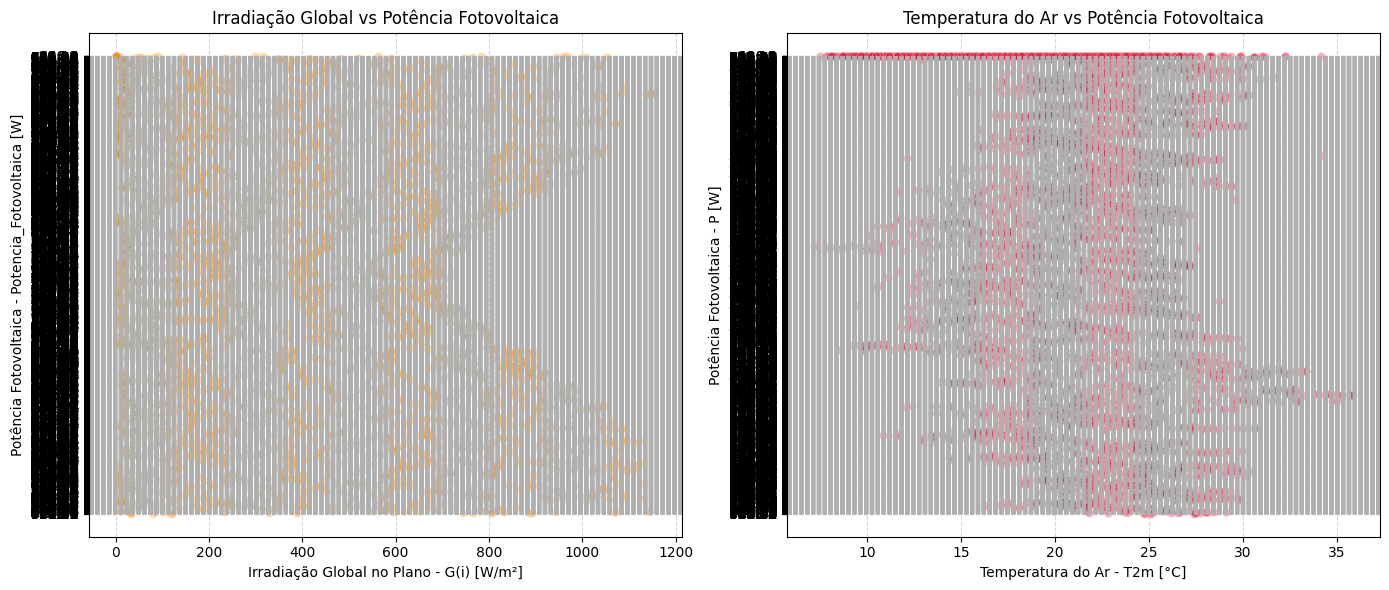

In [ ]:
# 5. Visualização e Relação entre Variáveis

# Configurações visuais dos gráficos
plt.figure(figsize=(14, 6))

# 1. Gráfico de Dispersão: Irradiação Global vs Potência
plt.subplot(1, 2, 1)
sns.scatterplot(x=df['Irradiancia_Solar'], y=df['Potencia_Fotovoltaica'], alpha=0.3, color='darkorange')
plt.title('Irradiação Global vs Potência Fotovoltaica')
plt.xlabel('Irradiação Global no Plano - G(i) [W/m²]')
plt.ylabel('Potência Fotovoltaica - Potencia_Fotovoltaica [W]')
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Gráfico de Dispersão: Temperatura do Ar vs Potência
plt.subplot(1, 2, 2)
sns.scatterplot(x=df['Temperatura'], y=df['Potencia_Fotovoltaica'], alpha=0.3, color='crimson')
plt.title('Temperatura do Ar vs Potência Fotovoltaica')
plt.xlabel('Temperatura do Ar - T2m [°C]')
plt.ylabel('Potência Fotovoltaica - P [W]')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~=~

Matriz de Correlação:


,Potencia_Fotovoltaica,Irradiancia_Solar,Temperatura,Velocidade_Vento,Altura_Solar
Potencia_Fotovoltaica,1.000000,0.999147,0.569799,0.204933,0.879881
Irradiancia_Solar,0.999147,1.000000,0.579743,0.195205,0.882467
Temperatura,0.569799,0.579743,1.000000,0.070726,0.564180
Velocidade_Vento,0.204933,0.195205,0.070726,1.000000,0.287501
Altura_Solar,0.879881,0.882467,0.564180,0.287501,1.000000


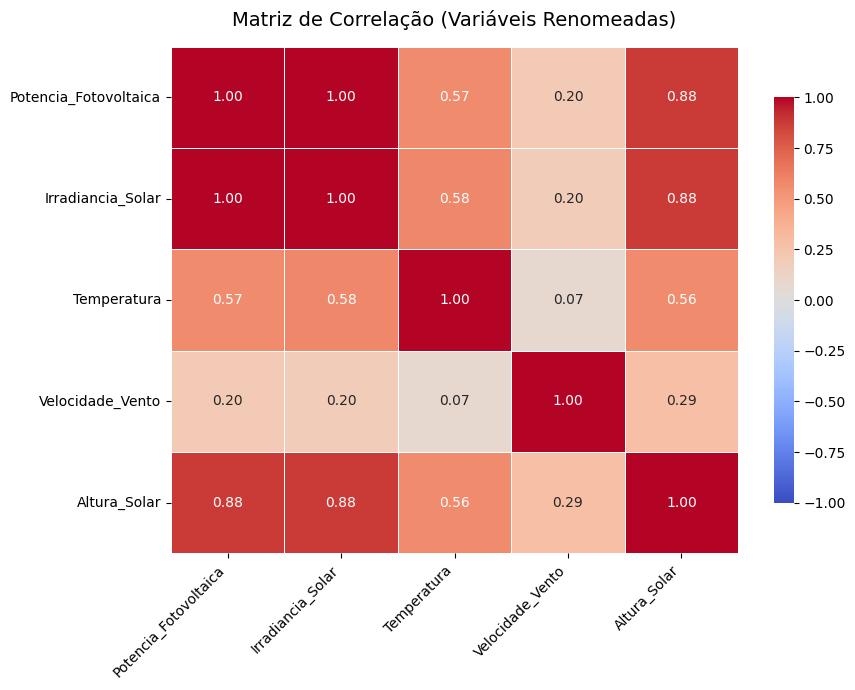

In [ ]:
# 6. Matriz de Correlação
print(f'\n{"=~" * 30}\n')
print('Matriz de Correlação:')

colunas_analise = [
    'Potencia_Fotovoltaica',
    'Irradiancia_Solar',
    'Temperatura',
    'Velocidade_Vento',
    'Altura_Solar'
]

# Filtrando apenas as colunas que existem no DataFrame
colunas_existentes = [col for col in colunas_analise if col in df.columns]

# Criando uma cópia temporária e convertendo as colunas para numérico (erros viram NaN)
df_corr = df[colunas_existentes].copy()
for col in colunas_existentes:
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')

# Calculando a matriz de correlação com os dados limpos
matriz_corr = df_corr.corr()

# Exibição segura
try:
    display(matriz_corr)
except NameError:
    print(matriz_corr)

# --- Mapa de Calor Aprimorado ---
plt.figure(figsize=(9, 7))

# Máscara para ocultar o triângulo superior (evita redundância)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(
    matriz_corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlação (Variáveis Renomeadas)', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# 7. Separação entre treinamento e teste


print('Separação entre Treinamento e Teste:')

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensões de X_train: {x_train.shape}")
print(f"Dimensões de X_test:  {x_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test:  {y_test.shape}")

Separação entre Treinamento e Teste:
Dimensões de X_train: (7027, 4)
Dimensões de X_test:  (1757, 4)
Dimensões de y_train: (7027,)
Dimensões de y_test:  (1757,)


In [ ]:
# 8. Modelo 1

print('Modelo 1 - Regressão Linear:')

# Criando o primeiro modelo de Regressão Linear
modeloLR1 = LinearRegression()

# Treinando o modelo utilizando X_train e y_train
modeloLR1.fit(x_train, y_train)

# Realizando previsões com X_test e armazenando em y_pred1
y_pred1 = modeloLR1.predict(x_test)

# Calculando as métricas MAE, MSE e R²
mae1 = mean_absolute_error(y_test, y_pred1)
mse1 = mean_squared_error(y_test, y_pred1)
r2_1 = r2_score(y_test, y_pred1)

# Exibindo os resultados obtidos
print(f"MAE (Erro Absoluto Médio): {mae1:.4f}")
print(f"MSE (Erro Quadrático Médio): {mse1:.4f}")
print(f"R² (Coeficiente de Determinação): {r2_1:.4f}")

# Registrando/armazenando os resultados para a comparação posterior
resultados_modelo1 = {
    'Modelo': 'Regressão Linear 1',
    'MAE': mae1,
    'MSE': mse1,
    'R2': r2_1
}

Modelo 1 - Regressão Linear:
MAE (Erro Absoluto Médio): 6.1178
MSE (Erro Quadrático Médio): 86.4386
R² (Coeficiente de Determinação): 0.9984


In [29]:
# 9. Modelo 2

# Criando novas váriaveis x e y
valores_x_2 = ['Irradiancia_Solar', 'Temperatura', 'Velocidade_Vento', 'Altura_Solar']
X2 = df[valores_x_2]
y2 = df['Potencia_Fotovoltaica']

# definindo valores de treino
x2_train, x2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Treinando segundo modelo
modeloLR2 = RandomForestRegressor(n_estimators=100, random_state=42)
modeloLR2.fit(x_train, y_train)

# Previsões
y2_pred = modeloLR2.predict(x_test)

# Métricas
print('Modelo 2 - modeloLR2:')
print(f"R² (Coeficiente de Determinação): {r2_score(y2_test, y2_pred):.4f}")
print(f"MSE (Erro Quadrático Médio): {mean_squared_error(y2_test, y2_pred):.4f}")

Modelo 2 - modeloLR2:
R² (Coeficiente de Determinação): 0.9998
MSE (Erro Quadrático Médio): 8.3083


In [30]:
# 10. Comparação dos Modelos

# Calcula as métricas para o Modelo 1 (ajuste os nomes das variáveis conforme o seu código)
y_pred_1 = modeloLR1.predict(x_test) # ou X_test do modelo 1
mae_1 = mean_absolute_error(y_test, y_pred_1)
mse_1 = mean_squared_error(y_test, y_pred_1)
r2_1 = r2_score(y_test, y_pred1)

# Calcular as métricas para o Modelo 2
y_pred_2 = modeloLR2.predict(x2_test)
mae_2 = mean_absolute_error(y2_test, y_pred_2)
mse_2 = mean_squared_error(y2_test, y_pred_2)
r2_2 = r2_score(y2_test, y_pred_2)

# Criar os dados da tabela
dados_tabela = {
    "Modelo": ["Modelo 1", "Modelo 2"],
    "Variáveis utilizadas": [
        str(list(X.columns)),
        str(list(X2.columns))
    ],
    "MAE": [mae_1, mae_2],
    "MSE": [mse_1, mse_2],
    "R²": [r2_1, r2_2]
}

# Transformar em um DataFrame do Pandas
df_comparacao = pd.DataFrame(dados_tabela)

# Exibir a tabela formatada
print('Tabela de Comparação dos Modelos:')
print(df_comparacao)

Tabela de Comparação dos Modelos:
     Modelo                               Variáveis utilizadas       MAE  \
0  Modelo 1  ['Irradiancia_Solar', 'Temperatura', 'Velocida...  6.117792   
1  Modelo 2  ['Irradiancia_Solar', 'Temperatura', 'Velocida...  1.284082   

         MSE        R²  
0  86.438629  0.998408  
1   8.308262  0.999847  


*11. Análise dos Resultados*

1. O modelo com maior R² foi o Modelo 2(RandomForestRegressor)
2. O modelo que apresentou o menor MAE foi o Modelo 2(RandomForestRegressor)
3. O modelo que apresentou o menor MSE foi o Modelo 2(RandomForestRegressor)
4. Sim, as 3 métricas apontam que o Modelo 2(RandomForestRegressor) é o melhor
5. Não, as variáveis com maior correlação nem sempre produzem o melhor modelo, uma vez que a correlação avalia apenas associações lineares simples e pode ser afetada por redundâncias ou ignorar interações complexas entre os dados.
6. Os gráficos de dispersão indicam que as relações não são perfeitamente lineares, apresentando comportamentos não-lineares, dispersões acentuadas e limites físicos de geração.
7. A previsão da potência fotovoltaica por modelos lineares é dificultada precisamente pela forte não-linearidade entre as variáveis meteorológicas e a energia gerada, pela intermitência climática imprevisível e pela enorme concentração de valores nulos durante o período noturno, que comprometem a precisão de abordagens lineares simples.